# Stage 4: Full Experiment Matrix

This notebook runs experiments E1-E4 (chunking ablation) and E6-E7 (agent architectures) on all test claims and compares results systematically.

| Exp | Chunking | Retrieval | Agent | What It Tests |
|-----|----------|-----------|-------|--------------|
| E1 | fixed | naive | single_pass | Baseline |
| E2 | semantic | hybrid_reranked | single_pass | Best RAG |
| E3 | section_aware | hybrid_reranked | single_pass | Section chunking |
| E4 | recursive | hybrid_reranked | single_pass | Recursive + metadata |
| E6 | semantic | hybrid_reranked | langgraph_multi | Multi-agent |
| E7 | semantic | hybrid_reranked | strands_rerouting | Adaptive rerouting |

**Note:** E5 (Strands multi-agent) requires AWS Bedrock. E8-E12 require OpenAI/Ollama.

In [1]:
import json
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Find project root (directory containing pyproject.toml)
_nb_dir = Path(os.path.abspath("")).resolve()
_project_root = _nb_dir
while _project_root != _project_root.parent:
    if (_project_root / "pyproject.toml").exists():
        break
    _project_root = _project_root.parent
os.chdir(_project_root)

sns.set_style("whitegrid")

SUBSET_SIZE = 5  # Set to None to process all claims

with open("data/test_claims.json") as f:
    claims = json.load(f)

if SUBSET_SIZE:
    claims = claims[:SUBSET_SIZE]

print(f"Running experiments on {len(claims)} claims")

Running experiments on 5 claims


## 4.1 Run all experiments

In [2]:
from src.pipelines.configurable import run_experiment
from src.experiment_runner import EXPERIMENT_CONFIGS

# Select experiments that work with Anthropic API only
EXPERIMENTS_TO_RUN = ["E1", "E2", "E3", "E4", "E6", "E7"]

all_results = {}

for exp_id in EXPERIMENTS_TO_RUN:
    config = EXPERIMENT_CONFIGS[exp_id]
    pipeline_config = {k: v for k, v in config.items() if k != "name"}
    
    print(f"\n{'='*60}")
    print(f"{exp_id}: {config['name']}")
    print(f"  {pipeline_config}")
    print(f"{'='*60}")
    
    exp_results = []
    for c in claims:
        print(f"  {c['claim'][:45]}...", end=" ", flush=True)
        try:
            result = run_experiment(c["claim"], **pipeline_config)
            result["expected_verdict"] = c["expected_verdict"]
            result["correct"] = result["verdict"] == c["expected_verdict"]
            exp_results.append(result)
            status = "OK" if result["correct"] else "WRONG"
            print(f"→ {result['verdict']} ({status}) {result['metadata']['latency_seconds']}s")
        except Exception as e:
            print(f"→ ERROR: {e}")
            exp_results.append({"claim": c["claim"], "verdict": "ERROR", "explanation": str(e), "evidence": [],
                                "metadata": {"latency_seconds": 0}, "expected_verdict": c["expected_verdict"], "correct": False})
    
    correct = sum(1 for r in exp_results if r.get("correct"))
    total_time = sum(r["metadata"]["latency_seconds"] for r in exp_results)
    print(f"  Result: {correct}/{len(exp_results)} correct, {total_time:.1f}s total")
    
    all_results[exp_id] = exp_results

print("\nAll experiments complete!")


E1: Baseline (P1 equivalent)
  {'chunking_strategy': 'fixed', 'retrieval_method': 'naive', 'agent_architecture': 'single_pass', 'model': 'claude-sonnet-4'}
  Vaccines cause autism... 

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

→ UNSUPPORTED (OK) 9.72s
  The MMR vaccine is linked to autism in childr... → UNSUPPORTED (OK) 7.59s
  Vitamin D supplements prevent COVID infection... → UNSUPPORTED (WRONG) 5.4s
  Intermittent fasting reverses Type 2 diabetes... → OVERSTATED (OK) 5.93s
  mRNA vaccines alter your DNA... → UNSUPPORTED (OK) 5.34s
  Result: 4/5 correct, 34.0s total

E2: Best RAG + single-pass
  {'chunking_strategy': 'semantic', 'retrieval_method': 'hybrid_reranked', 'agent_architecture': 'single_pass', 'model': 'claude-sonnet-4'}
  Vaccines cause autism... 

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


→ UNSUPPORTED (OK) 11.15s
  The MMR vaccine is linked to autism in childr... → UNSUPPORTED (OK) 6.68s
  Vitamin D supplements prevent COVID infection... → OVERSTATED (OK) 6.22s
  Intermittent fasting reverses Type 2 diabetes... → OVERSTATED (OK) 8.43s
  mRNA vaccines alter your DNA... → UNSUPPORTED (OK) 5.76s
  Result: 5/5 correct, 38.2s total

E3: Section-aware chunking
  {'chunking_strategy': 'section_aware', 'retrieval_method': 'hybrid_reranked', 'agent_architecture': 'single_pass', 'model': 'claude-sonnet-4'}
  Vaccines cause autism... → UNSUPPORTED (OK) 5.49s
  The MMR vaccine is linked to autism in childr... → UNSUPPORTED (OK) 6.01s
  Vitamin D supplements prevent COVID infection... → INSUFFICIENT_EVIDENCE (WRONG) 5.64s
  Intermittent fasting reverses Type 2 diabetes... → OVERSTATED (OK) 4.35s
  mRNA vaccines alter your DNA... → UNSUPPORTED (OK) 5.14s
  Result: 4/5 correct, 26.6s total

E4: Recursive chunking + metadata
  {'chunking_strategy': 'recursive', 'retrieval_method': 'hy

## 4.2 Accuracy comparison table

In [3]:
accuracy_table = []
for exp_id in EXPERIMENTS_TO_RUN:
    results = all_results[exp_id]
    config = EXPERIMENT_CONFIGS[exp_id]
    correct = sum(1 for r in results if r.get("correct"))
    total_time = sum(r["metadata"]["latency_seconds"] for r in results)
    avg_time = total_time / len(results)
    
    accuracy_table.append({
        "Experiment": exp_id,
        "Name": config["name"],
        "Accuracy": f"{correct}/{len(results)}",
        "Accuracy %": round(correct / len(results) * 100, 1),
        "Avg Latency (s)": round(avg_time, 1),
        "Total Time (s)": round(total_time, 1),
    })

df = pd.DataFrame(accuracy_table)
df

,Experiment,Name,Accuracy,Accuracy %,Avg Latency (s),Total Time (s)
0,E1,Baseline (P1 equivalent),4/5,80.0,6.8,34.0
1,E2,Best RAG + single-pass,5/5,100.0,7.6,38.2
2,E3,Section-aware chunking,4/5,80.0,5.3,26.6
3,E4,Recursive chunking + metadata,5/5,100.0,5.9,29.7
4,E6,Best RAG + LangGraph agents,5/5,100.0,22.4,111.9
5,E7,Best RAG + rerouting,5/5,100.0,50.3,251.4


## 4.3 Verdict matrix — which claims does each experiment get right?

In [4]:
verdict_matrix = pd.DataFrame()
verdict_matrix["Claim"] = [c["claim"][:40] for c in claims]
verdict_matrix["Expected"] = [c["expected_verdict"] for c in claims]

for exp_id in EXPERIMENTS_TO_RUN:
    results = all_results[exp_id]
    verdict_matrix[exp_id] = [
        f"{r['verdict']} {'Y' if r.get('correct') else ''}"
        for r in results
    ]

verdict_matrix

,Claim,Expected,E1,E2,E3,E4,E6,E7
0,Vaccines cause autism,UNSUPPORTED,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y
1,The MMR vaccine is linked to autism in c,UNSUPPORTED,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y
2,Vitamin D supplements prevent COVID infe,OVERSTATED,UNSUPPORTED,OVERSTATED Y,INSUFFICIENT_EVIDENCE,OVERSTATED Y,OVERSTATED Y,OVERSTATED Y
3,Intermittent fasting reverses Type 2 dia,OVERSTATED,OVERSTATED Y,OVERSTATED Y,OVERSTATED Y,OVERSTATED Y,OVERSTATED Y,OVERSTATED Y
4,mRNA vaccines alter your DNA,UNSUPPORTED,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y,UNSUPPORTED Y


## 4.4 Accuracy bar chart

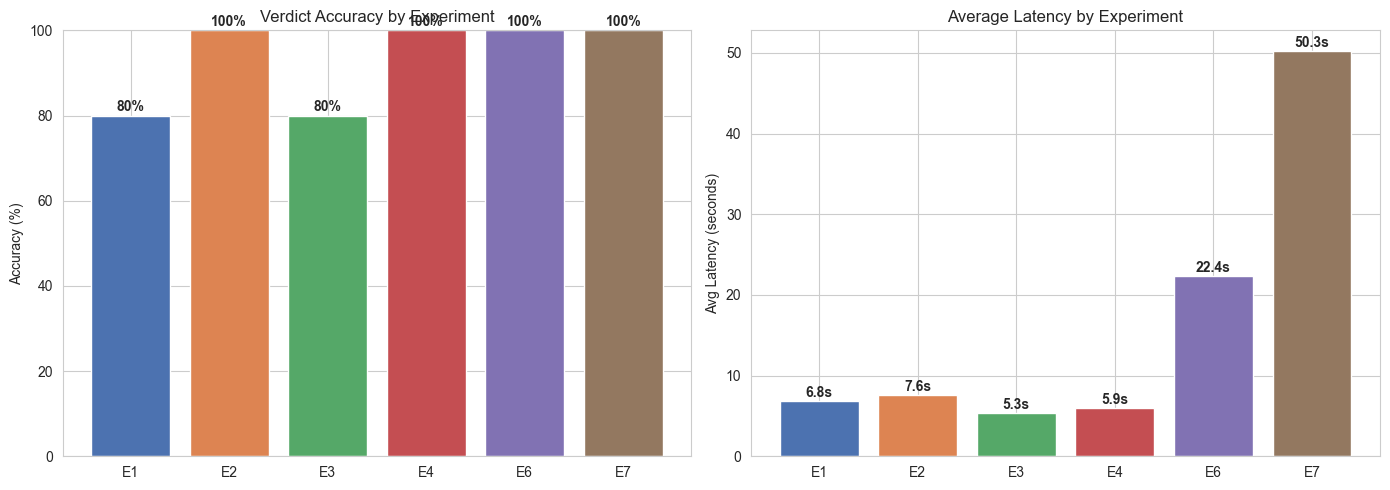

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
accuracies = [sum(1 for r in all_results[e] if r.get("correct")) / len(all_results[e]) * 100 for e in EXPERIMENTS_TO_RUN]
ax1.bar(EXPERIMENTS_TO_RUN, accuracies, color=colors)
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Verdict Accuracy by Experiment")
ax1.set_ylim(0, 100)
for i, v in enumerate(accuracies):
    ax1.text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold")

# Latency
avg_latencies = [sum(r["metadata"]["latency_seconds"] for r in all_results[e]) / len(all_results[e]) for e in EXPERIMENTS_TO_RUN]
ax2.bar(EXPERIMENTS_TO_RUN, avg_latencies, color=colors)
ax2.set_ylabel("Avg Latency (seconds)")
ax2.set_title("Average Latency by Experiment")
for i, v in enumerate(avg_latencies):
    ax2.text(i, v + 0.5, f"{v:.1f}s", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 4.5 Accuracy vs Latency scatter (cost-quality frontier)

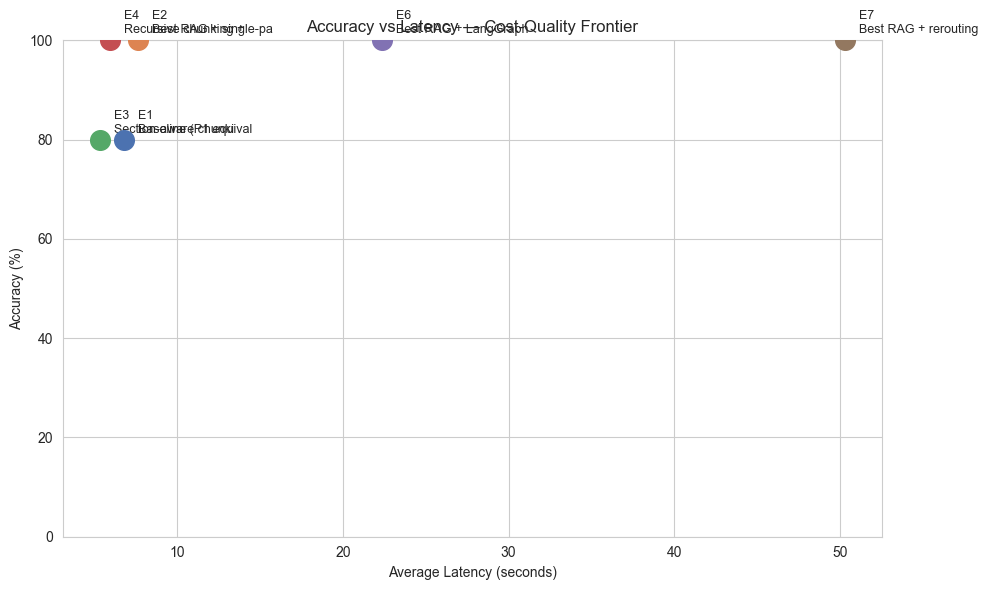

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, (exp_id, color) in enumerate(zip(EXPERIMENTS_TO_RUN, colors)):
    acc = accuracies[i]
    lat = avg_latencies[i]
    ax.scatter(lat, acc, s=200, c=color, zorder=5)
    ax.annotate(f"{exp_id}\n{EXPERIMENT_CONFIGS[exp_id]['name'][:20]}",
                (lat, acc), textcoords="offset points", xytext=(10, 5), fontsize=9)

ax.set_xlabel("Average Latency (seconds)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs Latency — Cost-Quality Frontier")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 4.6 Chunking ablation (E1 vs E2 vs E3 vs E4)

In [7]:
print("Chunking Ablation (all single-pass, E1 uses naive, E2-E4 use hybrid_reranked):")
print("=" * 70)
chunking_exps = ["E1", "E2", "E3", "E4"]

for i, c in enumerate(claims):
    verdicts = [all_results[e][i]["verdict"] for e in chunking_exps]
    correct_flags = ["Y" if all_results[e][i].get("correct") else " " for e in chunking_exps]
    agreement = len(set(verdicts)) == 1
    print(f"{c['claim'][:40]:<42} Expected={c['expected_verdict']:<15}  "
          f"E1={verdicts[0]:<12}[{correct_flags[0]}]  E2={verdicts[1]:<12}[{correct_flags[1]}]  "
          f"E3={verdicts[2]:<12}[{correct_flags[2]}]  E4={verdicts[3]:<12}[{correct_flags[3]}]  "
          f"{'AGREE' if agreement else 'DIFFER'}")

print(f"\nAccuracies: E1={accuracies[0]:.0f}%  E2={accuracies[1]:.0f}%  E3={accuracies[2]:.0f}%  E4={accuracies[3]:.0f}%")

Chunking Ablation (all single-pass, E1 uses naive, E2-E4 use hybrid_reranked):
Vaccines cause autism                      Expected=UNSUPPORTED      E1=UNSUPPORTED [Y]  E2=UNSUPPORTED [Y]  E3=UNSUPPORTED [Y]  E4=UNSUPPORTED [Y]  AGREE
The MMR vaccine is linked to autism in c   Expected=UNSUPPORTED      E1=UNSUPPORTED [Y]  E2=UNSUPPORTED [Y]  E3=UNSUPPORTED [Y]  E4=UNSUPPORTED [Y]  AGREE
Vitamin D supplements prevent COVID infe   Expected=OVERSTATED       E1=UNSUPPORTED [ ]  E2=OVERSTATED  [Y]  E3=INSUFFICIENT_EVIDENCE[ ]  E4=OVERSTATED  [Y]  DIFFER
Intermittent fasting reverses Type 2 dia   Expected=OVERSTATED       E1=OVERSTATED  [Y]  E2=OVERSTATED  [Y]  E3=OVERSTATED  [Y]  E4=OVERSTATED  [Y]  AGREE
mRNA vaccines alter your DNA               Expected=UNSUPPORTED      E1=UNSUPPORTED [Y]  E2=UNSUPPORTED [Y]  E3=UNSUPPORTED [Y]  E4=UNSUPPORTED [Y]  AGREE

Accuracies: E1=80%  E2=100%  E3=80%  E4=100%


## 4.7 Agent architecture comparison (E2 vs E6 vs E7)

In [8]:
print("Agent Architecture Comparison (all semantic + hybrid_reranked):")
print("=" * 70)
agent_exps = ["E2", "E6", "E7"]
agent_idx = [EXPERIMENTS_TO_RUN.index(e) for e in agent_exps]

for i, c in enumerate(claims):
    verdicts = [all_results[e][i]["verdict"] for e in agent_exps]
    latencies = [all_results[e][i]["metadata"]["latency_seconds"] for e in agent_exps]
    correct_flags = ["Y" if all_results[e][i].get("correct") else " " for e in agent_exps]
    
    print(f"{c['claim'][:40]:<42}  "
          f"SP={verdicts[0]:<15}[{correct_flags[0]}] {latencies[0]:>5.1f}s  "
          f"LG={verdicts[1]:<15}[{correct_flags[1]}] {latencies[1]:>5.1f}s  "
          f"RT={verdicts[2]:<15}[{correct_flags[2]}] {latencies[2]:>5.1f}s")

print(f"\nAccuracies: SP(E2)={accuracies[1]:.0f}%  LG(E6)={accuracies[4]:.0f}%  RT(E7)={accuracies[5]:.0f}%")
print(f"Avg latency: SP={avg_latencies[1]:.1f}s  LG={avg_latencies[4]:.1f}s  RT={avg_latencies[5]:.1f}s")

Agent Architecture Comparison (all semantic + hybrid_reranked):
Vaccines cause autism                       SP=UNSUPPORTED    [Y]  11.2s  LG=UNSUPPORTED    [Y]  23.6s  RT=UNSUPPORTED    [Y]  21.8s
The MMR vaccine is linked to autism in c    SP=UNSUPPORTED    [Y]   6.7s  LG=UNSUPPORTED    [Y]  22.1s  RT=UNSUPPORTED    [Y]  21.6s
Vitamin D supplements prevent COVID infe    SP=OVERSTATED     [Y]   6.2s  LG=OVERSTATED     [Y]  22.5s  RT=OVERSTATED     [Y]  67.6s
Intermittent fasting reverses Type 2 dia    SP=OVERSTATED     [Y]   8.4s  LG=OVERSTATED     [Y]  22.0s  RT=OVERSTATED     [Y]  67.8s
mRNA vaccines alter your DNA                SP=UNSUPPORTED    [Y]   5.8s  LG=UNSUPPORTED    [Y]  21.7s  RT=UNSUPPORTED    [Y]  72.6s

Accuracies: SP(E2)=100%  LG(E6)=100%  RT(E7)=100%
Avg latency: SP=7.6s  LG=22.4s  RT=50.3s


## 4.8 Save results for evaluation

In [9]:
from pathlib import Path

output_dir = Path("results/experiments")
output_dir.mkdir(parents=True, exist_ok=True)

for exp_id in EXPERIMENTS_TO_RUN:
    results = all_results[exp_id]
    config = EXPERIMENT_CONFIGS[exp_id]
    correct = sum(1 for r in results if r.get("correct"))
    
    output = {
        "experiment_id": exp_id,
        "config": config,
        "total_claims": len(results),
        "correct": correct,
        "accuracy": correct / len(results),
        "results": results,
    }
    
    path = output_dir / f"{exp_id}.json"
    with open(path, "w") as f:
        json.dump(output, f, indent=2)
    print(f"Saved {exp_id} to {path}")

print("\nDone! Results saved for Stage 5 evaluation.")

Saved E1 to results/experiments/E1.json
Saved E2 to results/experiments/E2.json
Saved E3 to results/experiments/E3.json
Saved E4 to results/experiments/E4.json
Saved E6 to results/experiments/E6.json
Saved E7 to results/experiments/E7.json

Done! Results saved for Stage 5 evaluation.


## Key Takeaways

**Chunking ablation (E1-E4):**
- Does semantic/section/recursive chunking improve over fixed?
- Is the improvement from better chunking or from better retrieval (hybrid vs naive)?

**Agent architecture (E2 vs E6 vs E7):**
- Does multi-agent improve verdict accuracy over single-pass?
- Does rerouting help on claims with weak initial evidence?
- Is the latency cost worth the quality gain?

**Next step:** Stage 5 runs formal evaluation metrics (Macro-F1, McNemar's test, LLM judge, bootstrap CIs).